# PROJET REMPLACENT ADRIEN THOMASSON DANS LES BIG 5 LEAGUES

# 1. Cadrage Stratégique & Rôle Tactique

### La Problématique Sportive
Le RC Lens doit pallier le départ potentiel d'Adrien Thomasson. Dans le système de jeu de l'équipe (généralement organisé autour d'un 3-4-2-1 ou 3-4-3 à haute intensité), Thomasson n'est pas un milieu de terrain classique. 

### Le Rôle Exact de Thomasson (Analyse Vidéo & Data)
* **Système & Hauteur de bloc :** Évolue dans un bloc haut, souvent dans les demi-espaces.
* **Intensité du pressing :** C'est le déclencheur du pressing lensois. Il harcèle le porteur dès la perte de balle (Contre-pressing).
* **Responsabilités dans la progression :** Il n'est pas le métronome qui dicte le tempo devant la défense (rôle du 6), mais le "connecteur" qui trouve la passe de rupture dans le dernier tiers.
* **Volume défensif :** Un abattage kilométrique élite, indispensable pour compenser les montées des pistons.

### Les 3 Profils de Succession (KPIs Prioritaires)
Puisque le marché ne propose pas de "clone absolu", nous allons paramétrer notre moteur de recherche (Thomasson Engine) pour proposer 3 options tactiques à la direction sportive, selon l'orientation que le coach souhaite donner à son équipe :

1. **Profil "8 Pressing" (Le Chien de Garde) :** Priorité au volume défensif, aux tacles, aux interceptions et à la résilience au sol. Idéal pour un milieu à deux très dense.
2. **Profil "10 Créatif" (Le Maître à Jouer) :** Priorité aux passes clés (Key Passes), aux passes dans le 3ème tiers et aux Expected Assists (xA). Idéal si l'équipe manque de créativité face aux blocs bas.
3. **Profil "Hybride Projection" (Le Box-to-Box) :** Priorité aux Expected Goals (xG), aux buts et à l'activité dans la surface adverse. Le profil le plus proche du Thomasson actuel.

Importation des bibliothèques et chargement des tables
On charge les fichiers bruts pour vérifier leur structure initiale.

In [67]:
# --- SECTION 1 :  ---
import pandas as pd
import glob
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt



### Problématique n°1 : Comment transformer des extraits de données fragmentés (top100, top200...) en une base de données unique, propre et exploitable pour le scouting ?

In [68]:
def load_league_data(directory_path, league_name):
    """
    Charge tous les fichiers CSV présents dans le dossier spécifié.
    """
    # Utilise *.csv pour attraper tous les fichiers du dossier
    search_pattern = os.path.join(directory_path, "*.csv")
    all_files = glob.glob(search_pattern)
    
    if not all_files:
        print(f"Aucun fichier .csv trouvé dans : {directory_path}")
        return pd.DataFrame()
    
    # Lecture et concaténation
    df_list = [pd.read_csv(f) for f in all_files]
    df = pd.concat(df_list, ignore_index=True)
    
    # Nettoyage des colonnes (Critique de l'expert : automatisation)
    df.columns = [c.replace('results__', '') for c in df.columns]
    df['league_name'] = league_name
    
    # Suppression des doublons (Critique de l'expert : gestion d'erreurs)
    df = df.drop_duplicates()
    
    print(f"{league_name} chargé : {len(df)} lignes.")
    return df

# --- CONFIGURATION DES CHEMINS ---
leagues = {
    "Ligue 1": "./Ligue1/",
    "Bundesliga": "./Bundesliga/",
    "La liga": "./Laliga/",
    "Premier League": "./PremierLeague/",
    "Serie A": "./SerieA/"
}

# --- EXÉCUTION ---
all_leagues_dfs = []
for name, path in leagues.items():
    df_l = load_league_data(path, name)
    if not df_l.empty:
        all_leagues_dfs.append(df_l)

if all_leagues_dfs:
    df_big5 = pd.concat(all_leagues_dfs, ignore_index=True)
    print(f"\n📊 TOTAL BIG 5 : {df_big5.shape[0]} joueurs et {df_big5.shape[1]} colonnes.")
else:
    print("❌ Erreur : Aucun fichier n'a été chargé.")
    
#afficher la colonne des noms de joueurs pour vérifier les données
df_big5.info()


Ligue 1 chargé : 1031 lignes.
Bundesliga chargé : 784 lignes.
La liga chargé : 1101 lignes.
Premier League chargé : 1029 lignes.
Serie A chargé : 1100 lignes.

📊 TOTAL BIG 5 : 5045 joueurs et 94 colonnes.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5045 entries, 0 to 5044
Data columns (total 94 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   goals                                                2527 non-null   float64
 1   expectedGoals                                        2094 non-null   float64
 2   assists                                              2527 non-null   float64
 3   expectedAssists                                      2482 non-null   float64
 4   rating                                               2527 non-null   float64
 5   yellowCards                                          2507 non-null   float64
 6   redCards                   

In [69]:
# 1. Chargement du fichier général
df_gen = pd.read_csv('./stats/general_Stats.csv')


# 3. Préparation des données

### ajouter Position et Age et Nation a la table big5

In [70]:
# On prend Joueur, Position, Nation, Age
df_pos = df_gen[['1_level_0_Player', '3_level_0_Pos', '2_level_0_Nation', '6_level_0_Age']].copy()
df_pos.columns = ['player__name', 'player_position', 'player_nation', 'player_age']

# Nettoyage : FBref met souvent "fr FRA" pour la nation et "28-150" pour l'âge
df_pos['player_nation'] = df_pos['player_nation'].str.split(' ').str[-1] # Garde juste "FRA"
df_pos['player_age'] = df_pos['player_age'].astype(str).str.split('-').str[0]       # Garde juste "28"

# 3. Supprimer les doublons dans FBref
cols_to_drop = ['player_position', 'player_nation', 'player_age']
for col in cols_to_drop:
    if col in df_big5.columns:
        df_big5 = df_big5.drop(columns=[col])

# 4. Fusion propre (Merge)
df_big5 = pd.merge(df_big5, df_pos, on='player__name', how='left')

# 5. Remplacement des vides (Fillna)
# Maintenant les colonnes existent à coup sûr et n'ont pas de suffixe _x ou _y
df_big5['player_position'] = df_big5['player_position'].fillna('Unknown')
df_big5['player_nation'] = df_big5['player_nation'].fillna('Unknown')
df_big5['player_age'] = pd.to_numeric(df_big5['player_age'], errors='coerce')

print(f"✅ Données démographiques intégrées. Total joueurs : {len(df_big5)}")
df_big5[['player__name', 'player_position', 'player_nation', 'player_age']].head(10)

✅ Données démographiques intégrées. Total joueurs : 5248


,player__name,player_position,player_nation,player_age
0,Lionel M'Pasi,Unknown,Unknown,NaN
1,NaN,Unknown,Unknown,NaN
2,Vitinha,"FW,MF",POR,25.0
3,Vitinha,MF,POR,26.0
4,NaN,Unknown,Unknown,NaN
5,Dilane Bakwa,MF,FRA,23.0
6,Dilane Bakwa,"FW,MF",FRA,23.0
7,NaN,Unknown,Unknown,NaN
8,Ousmane Dembélé,FW,FRA,28.0
9,NaN,Unknown,Unknown,NaN


### Supprimer les lignes Vides

In [71]:
# On supprime les lignes où le nom est manquant AVANT toute chose
df_big5 = df_big5.dropna(subset=['player__name'])

# 2. Préparation de la source FBref (df_pos)
df_gen = pd.read_csv('./stats/general_Stats.csv')
df_pos = df_gen[['1_level_0_Player', '3_level_0_Pos', '2_level_0_Nation', '6_level_0_Age']].copy()
df_pos.columns = ['player__name', 'player_position', 'player_nation', 'player_age']

# Nettoyage des chaînes
df_pos['player_nation'] = df_pos['player_nation'].astype(str).str.split(' ').str[-1]
df_pos['player_age'] = df_pos['player_age'].astype(str).str.split('-').str[0]

# --- CORRECTION DES DOUBLONS DANS LA SOURCE ---
# On trie par nom et on ne garde que la PREMIÈRE occurrence (souvent la plus complète)
# Cela évite de dupliquer les joueurs comme Vitinha lors du merge
df_pos = df_pos.drop_duplicates(subset=['player__name'], keep='first')

# 3. SÉCURITÉ : Nettoyage des colonnes existantes
cols_to_drop = ['player_position', 'player_nation', 'player_age']
for col in cols_to_drop:
    if col in df_big5.columns:
        df_big5 = df_big5.drop(columns=[col])

# 4. Fusion propre
df_big5 = pd.merge(df_big5, df_pos, on='player__name', how='left')

# 5. Finalisation des données
df_big5['player_position'] = df_big5['player_position'].fillna('Unknown')
df_big5['player_nation'] = df_big5['player_nation'].fillna('Unknown')
df_big5['player_age'] = pd.to_numeric(df_big5['player_age'], errors='coerce')

# Optionnel : Si un âge manque encore, on peut mettre l'âge médian pour ne pas avoir de NaN
df_big5['player_age'] = df_big5['player_age'].fillna(df_big5['player_age'].median())

print(f"✅ Pipeline de nettoyage terminé.")
print(f"📊 Taille du dataset : {len(df_big5)} joueurs réels (sans doublons).")
df_big5[['player__name', 'player_age', 'player_position', 'player_nation']]

✅ Pipeline de nettoyage terminé.
📊 Taille du dataset : 2730 joueurs réels (sans doublons).


,player__name,player_age,player_position,player_nation
0,Lionel M'Pasi,26.0,Unknown,Unknown
1,Vitinha,25.0,"FW,MF",POR
2,Vitinha,25.0,"FW,MF",POR
3,Dilane Bakwa,23.0,MF,FRA
4,Dilane Bakwa,23.0,MF,FRA
...,...,...,...,...
2725,Tjaš Begić,22.0,MF,SVN
2726,Andrea Le Borgne,26.0,Unknown,Unknown
2727,Joi Xheto Nuredini,26.0,Unknown,Unknown
2728,Cas Odenthal,25.0,DF,NED


## Problématique : Comment transformer un dataset "pollué" par des données de traduction en une matrice de scouting pure ? Nous allons filtrer les colonnes pour ne garder que l'identité du joueur et ses KPIs de performance.

Comment créer un marché unique ? Nous devons réunir les 5 ligues dans une seule matrice tout en gardant une trace de l'origine pour l'analyse de marché.

In [72]:
# Sélection des 22 colonnes (en enlevant les traductions)
cols_identite = ['player__name', 'player_position', 'player_nation', 'player_age', 'team__name', 'league_name', 'minutesPlayed', 'rating',]
cols_performance = [
    # --- MENACE (THREAT) ---
    'goals', 'expectedGoals', 'totalShots',
    
    # --- CRÉATIVITÉ & PLAYMAKING ---
    'assists', 'expectedAssists', 'bigChancesCreated', 
    'keyPasses', 'accurateFinalThirdPasses', 'accurateLongBalls', 
    'accuratePassesPercentage',
    
    # --- VOLUME & CONTRÔLE (RÉSILIENCE) ---
    'successfulDribbles', 'successfulDribblesPercentage', 
    'wasFouled', 'possessionLost', 'dispossessed',
    
    # --- COMBAT & PRESSING ---
    'tackles', 'interceptions', 'fouls',
    'groundDuelsWon', 'groundDuelsWonPercentage', 
    'aerialDuelsWon', 'aerialDuelsWonPercentage'
]

df_big5 = df_big5[cols_identite + cols_performance].copy()
df_big5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2730 entries, 0 to 2729
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   player__name                  2730 non-null   object 
 1   player_position               2730 non-null   object 
 2   player_nation                 2730 non-null   object 
 3   player_age                    2730 non-null   float64
 4   team__name                    2730 non-null   object 
 5   league_name                   2730 non-null   object 
 6   minutesPlayed                 2709 non-null   float64
 7   rating                        2730 non-null   float64
 8   goals                         2730 non-null   float64
 9   expectedGoals                 2274 non-null   float64
 10  totalShots                    2709 non-null   float64
 11  assists                       2730 non-null   float64
 12  expectedAssists               2680 non-null   float64
 13  big

## Problématique : Comment garantir que les joueurs identifiés ont un échantillon de données suffisant pour être comparés à Thomasson ? Un joueur ayant réussi 2 tacles en 10 minutes afficherait un taux de 18 tacles/90min, ce qui est une aberration statistique.

Je décide de lier le seuil de sélection au temps de jeu d'Adrien Thomasson. Nous retiendrons les joueurs ayant joué au moins 25% du temps de jeu de notre référence, ce qui assure une base de comparaison solide d'au moins 5 à 6 matchs.

In [73]:
# 1. Récupérer le temps de jeu de référence
thomasson_mins = df_big5[df_big5['player__name'].str.contains('Thomasson', na=False)]['minutesPlayed'].iloc[0]

# 2. Définir le seuil dynamique (25% du temps de jeu de la référence)
seuil_min = thomasson_mins * 0.25

print(f"Temps de jeu Thomasson : {thomasson_mins} min")
print(f"Seuil de fiabilité retenu : {seuil_min:.0f} min (25%)")

# 3. Application du filtre sur chaque championnat
df_big5[df_big5['minutesPlayed'] >= seuil_min]

# Vérification du nombre de joueurs restants
print(f"Nombre de joueurs conservés en Ligue 1 : {len(df_big5[df_big5['minutesPlayed'] >= seuil_min])}")

Temps de jeu Thomasson : 1922.0 min
Seuil de fiabilité retenu : 480 min (25%)
Nombre de joueurs conservés en Ligue 1 : 1674


### Suppression des doublons (Sécurité contre les chevauchements de fichiers topX)

In [74]:
# --- ÉTAPE : AGRÉGATION DES JOUEURS TRANSFÉRÉS (Ex: Wesley) ---

# 1. On définit comment on traite chaque type de colonne
agg_rules = {
    # --- IDENTITÉ ---
    'player_age': 'first',
    'player_position': 'first',
    'player_nation': 'first',
    'league_name': 'last',
    'team__name': lambda x: ' / '.join(x.unique()), # Ex: "Toulouse / Roma"
    
    # --- TEMPS DE JEU ---
    'minutesPlayed': 'sum',
    
    # --- MENACE (THREAT) ---
    'goals': 'sum',
    'expectedGoals': 'sum',
    'totalShots': 'sum',
    
    # --- CRÉATIVITÉ & PLAYMAKING ---
    'assists': 'sum',
    'expectedAssists': 'sum',
    'bigChancesCreated': 'sum',
    'keyPasses': 'sum',
    'accurateFinalThirdPasses': 'sum',
    'accurateLongBalls': 'sum',
    'accuratePassesPercentage': 'mean',
    
    # --- VOLUME & CONTRÔLE (RÉSILIENCE) ---
    'successfulDribbles': 'sum',
    'wasFouled': 'sum',
    'possessionLost': 'sum',
    'dispossessed': 'sum',
    'successfulDribblesPercentage': 'mean',
    
    # --- COMBAT & PRESSING ---
    'tackles': 'sum',
    'interceptions': 'sum',
    'fouls': 'sum',
    'groundDuelsWon': 'sum',
    'aerialDuelsWon': 'sum',
    'groundDuelsWonPercentage': 'mean',
    'aerialDuelsWonPercentage': 'mean',
    
    # --- NOTE GLOBALE ---
    'rating': 'mean'
}

# 2. On applique l'agrégation par nom de joueur
# On s'assure que les colonnes existent dans le dictionnaire pour éviter les erreurs
# 1. On effectue l'agrégation (votre code actuel est bon ici)
existing_cols = {k: v for k, v in agg_rules.items() if k in df_big5.columns}
df_big5 = df_big5.groupby('player__name', as_index=False).agg(existing_cols)

cols_to_fix = [c for c in cols_performance if c in df_big5.columns]


print(f"✅ Agrégation terminée. Les joueurs transférés ont désormais une ligne unique cumulée.")
display(df_big5[df_big5['player__name'].str.contains('Wesley', na=False)].head())
print("Colonnes disponibles dans le DataFrame final :", df_big5.columns.tolist())

✅ Agrégation terminée. Les joueurs transférés ont désormais une ligne unique cumulée.


,player__name,player_age,player_position,player_nation,league_name,team__name,minutesPlayed,goals,expectedGoals,totalShots,...,dispossessed,successfulDribblesPercentage,tackles,interceptions,fouls,groundDuelsWon,aerialDuelsWon,groundDuelsWonPercentage,aerialDuelsWonPercentage,rating
2337,Wesley,22.0,MF,BRA,Serie A,Real Sociedad / Roma,4042.0,6.0,2.68,42.0,...,44.0,62.965,92.0,34.0,60.0,212.0,40.0,48.865,73.075,6.74
2338,Wesley Fofana,25.0,DF,FRA,Premier League,Chelsea,1026.0,0.0,0.25,2.0,...,3.0,71.430,15.0,23.0,15.0,35.0,49.0,58.330,66.220,7.05
2339,Wesley Saïd,30.0,MF,FRA,Ligue 1,RC Lens,1546.0,10.0,7.59,41.0,...,17.0,63.640,16.0,9.0,30.0,49.0,14.0,43.750,40.000,7.19


Colonnes disponibles dans le DataFrame final : ['player__name', 'player_age', 'player_position', 'player_nation', 'league_name', 'team__name', 'minutesPlayed', 'goals', 'expectedGoals', 'totalShots', 'assists', 'expectedAssists', 'bigChancesCreated', 'keyPasses', 'accurateFinalThirdPasses', 'accurateLongBalls', 'accuratePassesPercentage', 'successfulDribbles', 'wasFouled', 'possessionLost', 'dispossessed', 'successfulDribblesPercentage', 'tackles', 'interceptions', 'fouls', 'groundDuelsWon', 'aerialDuelsWon', 'groundDuelsWonPercentage', 'aerialDuelsWonPercentage', 'rating']


### Regler le probleme de Nan Pour que ne produise pas un erreur si on veut faire une comparaison remplace nan par 0

In [75]:
#Gestion des NaNs
# Pour les stats de performance, on remplace par 0
df_big5[cols_to_fix] = df_big5[cols_to_fix].fillna(0)
df_big5['expectedGoals']

0       0.41
1       0.00
2       0.00
3       0.52
4       0.00
        ... 
2440    0.98
2441    0.00
2442    0.12
2443    0.00
2444    0.00
Name: expectedGoals, Length: 2445, dtype: float64

### Pour les minutes, on supprime les joueurs sans temps de jeu (impossible de calculer le p90 sinon)

In [76]:
df_big5 = df_big5.dropna(subset=['minutesPlayed'])
check_thomasson = df_big5[df_big5['player__name'].str.contains('Thomasson', na=False)]
print(f"Joueurs initiaux : {len(df_big5)}")
print(f"Joueurs après de-duplication et filtrage (> {seuil_min:.0f} min) : {len(df_big5)}")

if not check_thomasson.empty:
    print(f" Adrien Thomasson est bien présent dans la base finale.")
else:
    print(f" ATTENTION : Adrien Thomasson a disparu ! Vérifie les filtres.")
    
df_big5

Joueurs initiaux : 2445
Joueurs après de-duplication et filtrage (> 480 min) : 2445
 Adrien Thomasson est bien présent dans la base finale.


,player__name,player_age,player_position,player_nation,league_name,team__name,minutesPlayed,goals,expectedGoals,totalShots,...,dispossessed,successfulDribblesPercentage,tackles,interceptions,fouls,groundDuelsWon,aerialDuelsWon,groundDuelsWonPercentage,aerialDuelsWonPercentage,rating
0,Aaron Hickey,23.0,DF,SCO,Premier League,Brentford,617.0,0.0,0.41,5.0,...,5.0,0.00,12.0,7.0,6.0,20.0,9.0,46.51,50.00,6.56
1,Aaron Ramsdale,27.0,GK,ENG,Premier League,Newcastle United,553.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,2.0,0.00,100.00,6.57
2,Aaron Wan-Bissaka,28.0,"DF,MF",COD,Premier League,West Ham United,1553.0,0.0,0.00,0.0,...,11.0,44.83,24.0,31.0,17.0,49.0,18.0,50.00,52.94,6.68
3,Aaron Zehnter,21.0,DF,GER,Bundesliga,VfL Wolfsburg,1208.0,2.0,0.52,8.0,...,0.0,66.67,12.0,16.0,1.0,16.0,8.0,66.67,30.77,6.61
4,Aarón Anselmino,26.0,Unknown,Unknown,Ligue 1,RC Strasbourg,11.0,0.0,0.00,0.0,...,0.0,0.00,0.0,1.0,0.0,0.0,0.0,0.00,0.00,6.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2440,Óscar Valentín,31.0,MF,ESP,La liga,Rayo Vallecano,1395.0,1.0,0.98,12.0,...,4.0,0.00,46.0,18.0,20.0,58.0,20.0,53.70,40.82,6.84
2441,Ørjan Nyland,35.0,GK,NOR,La liga,Sevilla,360.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,1.0,0.00,100.00,6.65
2442,Þórir Jóhann Helgason,25.0,MF,ISL,Serie A,Lecce,115.0,0.0,0.12,2.0,...,1.0,80.00,1.0,1.0,0.0,5.0,0.0,71.43,0.00,6.55
2443,Đorđe Petrović,26.0,GK,SRB,Premier League,Bournemouth,2430.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,2.0,15.0,40.00,100.00,6.88


In [77]:
thomasson_pos = df_big5[df_big5['player__name'].str.contains('Thomasson', na=False)]
print(f"Position détectée pour Thomasson : {thomasson_pos['player_position'].iloc[0]}")

Position détectée pour Thomasson : MF


j'avais dans player_position 1403 non nulle ce qui veut dire il reste 1600-1403 = 197 joeuers qui la valeur Nan donc j'ai changer cette valeur en Unknown pour eviter les problemes a venir 

In [78]:
df_big5['player_position'] = df_big5['player_position'].fillna('Unknown')
df_big5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2445 entries, 0 to 2444
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   player__name                  2445 non-null   object 
 1   player_age                    2445 non-null   float64
 2   player_position               2445 non-null   object 
 3   player_nation                 2445 non-null   object 
 4   league_name                   2445 non-null   object 
 5   team__name                    2445 non-null   object 
 6   minutesPlayed                 2445 non-null   float64
 7   goals                         2445 non-null   float64
 8   expectedGoals                 2445 non-null   float64
 9   totalShots                    2445 non-null   float64
 10  assists                       2445 non-null   float64
 11  expectedAssists               2445 non-null   float64
 12  bigChancesCreated             2445 non-null   float64
 13  key

# 4. Feature Engineering & Standardisation

 ### Problematique : Comment comparer équitablement un titulaire indiscutable et un remplaçant efficace ? Pour trouver le "clone" de Thomasson, nous devons ramener toutes les données sur une base commune de 90 minutes. Nous allons aussi créer le Pressing Index, qui est la signature tactique recherchée pour remplacer Adrien.

In [79]:
# On travaille sur la table propre (déjà filtrée > 900 min)
df_final = df_big5.copy()

# --- SÉCURITÉ : NETTOYAGE DES VALEURS INFINIES ET TYPES ---
# On convertit TOUTES les colonnes de pourcentages en nombres purs
cols_percentages = [
    'groundDuelsWonPercentage', 'aerialDuelsWonPercentage', 
    'accuratePassesPercentage', 'successfulDribblesPercentage'
]

for col in cols_percentages:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# --- 2. AJUSTEMENT PAR MINUTES JOUÉES (P90) ---
df_final['90s'] = df_final['minutesPlayed'] / 90

# La NOUVELLE liste des compteurs à ramener sur 90 minutes
cols_to_normalize = [
    'goals', 'expectedGoals', 'totalShots',
    'assists', 'expectedAssists', 'bigChancesCreated', 'keyPasses', 
    'accurateFinalThirdPasses', 'accurateLongBalls',
    'successfulDribbles', 'wasFouled', 'possessionLost', 'dispossessed',
    'tackles', 'interceptions', 'fouls', 'groundDuelsWon', 'aerialDuelsWon'
]

# Calcul automatique des colonnes _p90 (Sécurisé avec np.where)
for col in cols_to_normalize:
    df_final[f'{col}_p90'] = np.where(df_final['90s'] > 0, df_final[col] / df_final['90s'], 0)

# --- SÉCURITÉ ANTI-WARNING (Placée APRÈS les calculs) ---
df_final = df_final.replace([np.inf, -np.inf], np.nan)
df_final = df_final.fillna(0)

# --- 3. Z-SCORE INTRA-LIGUE (NORMALISATION INTER-LEAGUES) ---
# Astuce Pro : On génère la liste automatiquement avec toutes nos nouvelles stats P90 + nos pourcentages
cols_for_zscore = [f'{col}_p90' for col in cols_to_normalize] + cols_percentages

def compute_zscore(x):
    std = x.std(ddof=0)
    if std == 0 or pd.isna(std):
        return x - x.mean()
    return (x - x.mean()) / std

for col in cols_for_zscore:
    df_final[f'{col}_z'] = df_final.groupby('league_name')[col].transform(compute_zscore)   

# --- CRÉATION DE L'INDEX DE PRESSING (Base du volume défensif) ---
df_final['pressing_index_z'] = df_final['tackles_p90_z'] + df_final['interceptions_p90_z']

print("✅ Feature Engineering terminé : P90 calculés et Z-Scores intra-ligues générés pour les nouvelles metrics élites.")

✅ Feature Engineering terminé : P90 calculés et Z-Scores intra-ligues générés pour les nouvelles metrics élites.


### Calcul des Scores

In [ ]:
# 1. PLAYMAKING (Vision, Création, et Cassage de lignes)
df_final['playmaking_score_z'] = (
    df_final['accurateFinalThirdPasses_p90_z'] * 0.30 +  # Casser les lignes
    df_final['keyPasses_p90_z'] * 0.20 +                 # Passes clés
    df_final['expectedAssists_p90_z'] * 0.20 +           # Qualité de la passe
    df_final['bigChancesCreated_p90_z'] * 0.20 +         # NOUVEAU : La stat élite de création pure
    df_final['accurateLongBalls_p90_z'] * 0.10           # NOUVEAU : Renversement de jeu
)

# 2. RESILIENCE (Résistance à la pression et conservation du ballon)
# Attention : se faire prendre le ballon est négatif, on soustrait donc ces Z-scores !
df_final['resilience_score_z'] = (
    df_final['groundDuelsWonPercentage_z'] * 0.30 +      # Taux de réussite au duel
    df_final['successfulDribbles_p90_z'] * 0.30 +        # NOUVEAU : Casser le pressing par le dribble
    df_final['wasFouled_p90_z'] * 0.20 -                 # NOUVEAU : Obtenir des fautes (soulager l'équipe)
    df_final['possessionLost_p90_z'] * 0.10 -            # NOUVEAU (Pénalité) : Pertes de balles globales
    df_final['dispossessed_p90_z'] * 0.10                # NOUVEAU (Pénalité) : Se faire subtiliser le ballon
)

# 3. THREAT (Menace et Dangerosité dans la surface)
df_final['threat_score_z'] = (
    df_final['expectedGoals_p90_z'] * 0.45 +             # Qualité des positions de tir
    df_final['goals_p90_z'] * 0.35 +                     # Finition réelle
    df_final['totalShots_p90_z'] * 0.20                  # NOUVEAU : Volume d'activité offensive
)

# 4. PRESSING (Activité défensive et récupération)
df_final['pressing_score_z'] = (
    df_final['tackles_p90_z'] * 0.40 +                   # Grattage de ballons
    df_final['interceptions_p90_z'] * 0.40 +             # Lecture des lignes de passes
    df_final['groundDuelsWon_p90_z'] * 0.20              # NOUVEAU : Volume pur de combativité au sol
)

### PERCENTILES GLOBAUX (Pour le graphique Radar et la Similarité)

In [ ]:
scores_z = ['pressing_score_z', 'playmaking_score_z', 'resilience_score_z', 'threat_score_z']
scores_finaux = ['pressing_score', 'playmaking_score', 'resilience_score', 'threat_score']

for z_col, final_col in zip(scores_z, scores_finaux):
    # On classe l'ensemble des joueurs d'Europe sur leur Z-Score pondéré
    df_final[final_col] = df_final[z_col].rank(pct=True) * 100

# Calcul des percentiles annexes (Rating + Stats Détaillées pour Radars)
df_final['rating_pct'] = df_final['rating'].rank(pct=True) * 100

colonnes_brutes = [
    'tackles_p90', 'interceptions_p90', 'accurateFinalThirdPasses_p90', 
    'keyPasses_p90', 'expectedAssists_p90', 'expectedGoals_p90', 
    'goals_p90', 'groundDuelsWonPercentage'
]
for col in colonnes_brutes:
    df_final[f'{col}_pct'] = df_final[col].rank(pct=True) * 100

# --- VÉRIFICATION ---
thomasson_check = df_final[df_final['player__name'].str.contains('Thomasson', na=False)]
print("✅ Pipeline Mathématique (Z-Score + Poids) terminé.")
print("Voici le profil affiné de Thomasson (Notes sur 100) :")
display(thomasson_check[['player__name', 'pressing_score', 'playmaking_score', 'resilience_score', 'threat_score', 'rating_pct']].round(1))

✅ Pipeline Mathématique (Z-Score + Poids) terminé.
Voici le profil affiné de Thomasson (Notes sur 100) :


,player__name,pressing_score,playmaking_score,resilience_score,threat_score,rating_pct
57,Adrien Thomasson,71.7,77.3,35.1,76.6,75.3


### Problématique : Un score de 5.7 en pressing est-il performant ? Pour comparer des statistiques de natures différentes (buts vs tacles), nous convertissons chaque performance en percentile (de 0 à 100). Cela permet de situer chaque joueur par rapport à la moyenne du Big 5.

Analyse : Cela confirme scientifiquement le profil de Thomasson. Il est excellent pour se projeter et se retrouver dans des situations de tir (xG élevé), mais il est moins "tueur" ou "clinique" dans la finition que des attaquants de métier. C'est exactement ce que l'on attend d'un milieu box-to-box qui travaille énormément.

# 5. Modélisation de similarité (Cosinus)

### Problématique : Comment identifier mathématiquement les joueurs ayant le profil le plus proche de Thomasson ? Nous utilisons la Similarité Cosinus sur nos 4 piliers tactiques (ADN) pour obtenir un score de ressemblance de 0 à 100%.

In [ ]:


# 1. On définit les caractéristiques qui forment l'ADN du joueur
features_dna = ['pressing_score', 'playmaking_score', 'resilience_score', 'threat_score']
df_final[features_dna] = df_final[features_dna].fillna(0)

# --- MATRICE DE PONDÉRATION TACTIQUE (LES 3 PROFILS) ---
tactical_profiles = {
    "Profil 8 Pressing": {
        'pressing_score': 2.0,    # 200% (Ultra prioritaire)
        'playmaking_score': 0.8,  # 80% (Secondaire)
        'resilience_score': 1.5,  # 150% (Très important pour les duels)
        'threat_score': 0.5       # 50% (Peu d'importance sur les buts)
    },
    "Profil 10 Créatif": {
        'pressing_score': 0.8,    
        'playmaking_score': 2.0,  # 200% (La vision de jeu d'abord)
        'resilience_score': 0.8,  
        'threat_score': 1.2       
    },
    "Profil Hybride Projection": {
        'pressing_score': 1.2,    
        'playmaking_score': 1.2,  
        'resilience_score': 1.0,  
        'threat_score': 1.8       # 180% (Priorité à la surface de réparation, xG)
    }
}
print("✅ Matrice des rôles tactiques chargée.")

# fonction de recherche de similarité avec pondération tactique
def run_replacement_model(df, target_name="Adrien Thomasson", profile_name="Profil 8 Pressing"):
    """
    Fonction professionnelle de scouting : 
    Recherche les joueurs similaires selon un profil tactique défini.
    """
    print(f"🔍 Lancement du moteur pour remplacer {target_name} avec le {profile_name}...")
    
    # 1. Copie du dataframe et récupération des poids
    df_weighted = df[features_dna].copy()
    weights = tactical_profiles[profile_name]
    
    # 2. Application des poids tactiques
    for col, weight in weights.items():
        df_weighted[col] = df_weighted[col] * weight
        
    # 3. Extraction du Vecteur Cible
    target_vector = df_weighted[df['player__name'].str.contains(target_name, na=False)].values
    
    if len(target_vector) == 0:
        return print("❌ Joueur cible introuvable.")
        
    # 4. Calcul de similarité Cosinus
    similarity_array = cosine_similarity(df_weighted, target_vector)
    
    # 5. Ajout au DataFrame et tri
    df_result = df.copy()
    df_result['similarity_score'] = similarity_array.flatten() * 100
    
    # On exclut le joueur cible de sa propre liste de clones
    top_candidats = df_result[~df_result['player__name'].str.contains(target_name, na=False)].sort_values(by='similarity_score', ascending=False)
    
    return top_candidats


# On choisit par exemple de chercher le "Profil 8 Pressing" (le profil naturel de Lens)
profil_choisi = "Profil 8 Pressing" 
top_clones = run_replacement_model(df_final, target_name="Adrien Thomasson", profile_name=profil_choisi)

# On met à jour notre df_final avec ces nouveaux scores pour la suite du notebook
df_final['similarity_score'] = top_clones['similarity_score']

print(f"\n✅ Moteur de similarité PONDÉRÉ activé.")
print(f"Comparaison effectuée sur {len(df_final)} joueurs.")
print("---")
print(f"Top 20 des profils les plus proches (Mode : {profil_choisi}) :")
display(top_clones[['player__name', 'player_age' ,'team__name','player_position', 'league_name', 'similarity_score']].head(20).round(2))

✅ Matrice des rôles tactiques chargée.
🔍 Lancement du moteur pour remplacer Adrien Thomasson avec le Profil 8 Pressing...

✅ Moteur de similarité PONDÉRÉ activé.
Comparaison effectuée sur 2445 joueurs.
---
Top 20 des profils les plus proches (Mode : Profil 8 Pressing) :


,player__name,player_age,team__name,player_position,league_name,similarity_score
1670,Morgan Bokele Mputu,26.0,Metz,Unknown,Ligue 1,99.99
635,Emile Smith Rowe,25.0,Fulham,MF,Premier League,99.99
106,Alessio Zerbin,26.0,Cremonese,MF,Serie A,99.98
1942,Rafik Belghali,23.0,Hellas Verona,MF,Serie A,99.95
2047,Ryan Christie,30.0,Bournemouth,MF,Premier League,99.95
2074,Samuel Amo-Ameyaw,19.0,RC Strasbourg,"MF,DF",Ligue 1,99.95
1777,Noah Edjouma,20.0,Lille,FW,Ligue 1,99.95
1932,Quinten Timber,24.0,Olympique de Marseille,MF,Ligue 1,99.92
33,Adam Boayar,20.0,Elche,MF,La liga,99.92
930,Iliman Ndiaye,25.0,Everton,MF,Premier League,99.89


Analyse : en utilisant la similiraty score j'ai pu detecter les joueurs qui se ressemble a thomasson si on groupe les 4 piliers ou metique qu'on a calculer avant

### 

check l'ensemble des positions que j'ai dans mon player_position

In [83]:
positions_uniques = (
    df_big5["player_position"]
    .str.split(",")      # sépare "MF,FW" → ["MF", "FW"]
    .explode()           # met chaque position sur une ligne
    .str.strip()         # enlève les espaces éventuels
    .unique()            # récupère les valeurs uniques
)

print(sorted(positions_uniques))
print("Nombre total :", len(positions_uniques))

['DF', 'FW', 'GK', 'MF', 'Unknown']
Nombre total : 5


In [84]:
df_big5.info()
top_clones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2445 entries, 0 to 2444
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   player__name                  2445 non-null   object 
 1   player_age                    2445 non-null   float64
 2   player_position               2445 non-null   object 
 3   player_nation                 2445 non-null   object 
 4   league_name                   2445 non-null   object 
 5   team__name                    2445 non-null   object 
 6   minutesPlayed                 2445 non-null   float64
 7   goals                         2445 non-null   float64
 8   expectedGoals                 2445 non-null   float64
 9   totalShots                    2445 non-null   float64
 10  assists                       2445 non-null   float64
 11  expectedAssists               2445 non-null   float64
 12  bigChancesCreated             2445 non-null   float64
 13  key

In [85]:
# 1. On filtre pour ne garder que les Milieux (MF) et les profils sans position connue (Unknown)
# On prend les 30 meilleurs après ce filtre
top_mf = top_clones[top_clones['player_position'].str.contains('MF|Unknown', na=False)]

print("🎯 LE TOP DES CLONES DE THOMASSON (MILIEUX)")
top_mf[['player__name','player_position','player_age', 'player_nation', 'team__name', 'league_name', 'similarity_score', 'rating_pct']].round(2)

🎯 LE TOP DES CLONES DE THOMASSON (MILIEUX)


,player__name,player_position,player_age,player_nation,team__name,league_name,similarity_score,rating_pct
1670,Morgan Bokele Mputu,Unknown,26.0,Unknown,Metz,Ligue 1,99.99,36.38
635,Emile Smith Rowe,MF,25.0,ENG,Fulham,Premier League,99.99,47.73
106,Alessio Zerbin,MF,26.0,ITA,Cremonese,Serie A,99.98,25.73
1942,Rafik Belghali,MF,23.0,ALG,Hellas Verona,Serie A,99.95,55.13
2047,Ryan Christie,MF,30.0,SCO,Bournemouth,Premier League,99.95,36.38
...,...,...,...,...,...,...,...,...
1157,José Luis Pérez,Unknown,26.0,Unknown,Getafe,La liga,36.95,14.93
603,Eder Garcia,Unknown,26.0,Unknown,Athletic Club,La liga,36.85,14.93
487,Dani Pérez,Unknown,26.0,Unknown,Real Betis,La liga,35.41,0.74
2431,Álvaro Valles,Unknown,26.0,Unknown,Real Betis,La liga,34.09,89.33


Analyse : Amin Sarr (99.9% de similarité) : C'est le "jumeau" statistique parfait en termes de style (il fait les mêmes choses que Thomasson dans les mêmes proportions). Cependant, son rating_pct est de 5.03. Cela signifie qu'il a le bon profil, mais qu'il a fait une saison très compliquée.

Antonio Vergara (99.63% / 78.75 rating) : Une piste italienne très sérieuse de 23 ans.

Rubén García (99.62% / 69.94 rating) : Un profil interessant qui joue à Osasuna en Espagne mais il a 32 ans donc je fais un filtre encore pour selectionner les moins de 30 ans.

Kévin Danois (99.57% de similarité) : C'est probablement La meilleure piste. Il est très proche de Thomasson, il a seulement 21 ans, il joue déjà en Ligue 1 (Auxerre), et surtout, il a un rating_pct de 81.47. Statistiquement, c'est un joueur de haut niveau avec l'ADN exact de Thomasson.


In [86]:
top_mf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464 entries, 1670 to 1302
Data columns (total 90 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   player__name                      1464 non-null   object 
 1   player_age                        1464 non-null   float64
 2   player_position                   1464 non-null   object 
 3   player_nation                     1464 non-null   object 
 4   league_name                       1464 non-null   object 
 5   team__name                        1464 non-null   object 
 6   minutesPlayed                     1464 non-null   float64
 7   goals                             1464 non-null   float64
 8   expectedGoals                     1464 non-null   float64
 9   totalShots                        1464 non-null   float64
 10  assists                           1464 non-null   float64
 11  expectedAssists                   1464 non-null   float64
 12  bigChanc

player_age est de type object je dois le remettre en numeric pourque je puiise ajouter la condition moins de 30 ans
et ajouter aussi une condition le rating pourcentage doit etre sup à 60% et similarity_score >= 99

In [87]:
top_mf["player_age"] = pd.to_numeric(top_mf["player_age"], errors="coerce")
top_mf_clean = top_mf[
    (top_mf["similarity_score"] >= 98.0) & 
    (top_mf["player_age"] <= 30) & 
    (top_mf["rating_pct"] > 65.0)
].copy()
top_mf_clean = top_mf_clean[[
    'player__name', 'team__name', 'league_name', 'similarity_score',
    'rating_pct', 'player_position', 'player_age', 'player_nation'
]].round(2)

top_mf_clean = top_mf_clean.sort_values(by='rating_pct', ascending=False)
top_mf_clean

C:\Users\33766\AppData\Local\Temp\ipykernel_10128\3511846343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mf["player_age"] = pd.to_numeric(top_mf["player_age"], errors="coerce")


,player__name,team__name,league_name,similarity_score,rating_pct,player_position,player_age,player_nation
1347,Lionel M'Pasi,Le Havre,Ligue 1,99.10,99.84,Unknown,26.0,Unknown
139,Alisson Santos,Napoli,Serie A,99.09,99.75,MF,23.0,BRA
701,Federico Dimarco,Inter,Serie A,99.83,99.26,MF,28.0,ITA
356,Bruno Guimarães,Newcastle United,Premier League,98.82,98.96,MF,28.0,BRA
1734,Nico Paz,Como,Serie A,98.70,97.83,Unknown,26.0,Unknown
...,...,...,...,...,...,...,...,...
349,Brenden Aaronson,Leeds United,Premier League,99.88,66.11,"FW,MF",25.0,USA
746,Fran Beltrán,Girona FC,La liga,99.43,66.11,MF,27.0,ESP
174,Andrei Rațiu,Rayo Vallecano,La liga,99.22,66.11,Unknown,26.0,Unknown
983,Jaidon Anthony,Burnley,Premier League,98.55,66.11,MF,26.0,ENG


# 6. Entonnoir de Sélection
Notre méthodologie suit une logique d'entonnoir pour isoler la perle rare :

1.  **Le Réservoir Initial (2445 joueurs) :**  Analyse exhaustive de l'intégralité des joueurs évoluant dans les 5 grands championnats européens (Big 5). Cette base de données constitue notre point de départ global.

2.  **La Spécialisation (1465 joueurs) :** Restriction de la recherche aux milieux de terrain (MF). Cette étape assure que le candidat possède les bases métier nécessaires pour occuper le rôle de "connecteur" entre la défense et l'attaque artésienne.

3.  **Le Filtrage ADN (228 joueurs) :** Utilisation de la similarité cosinus avec un seuil de 98%. Ce réglage a été optimisé pour capturer les "clones" parfaits de Thomasson tout en offrant la flexibilité nécessaire pour inclure des profils à plus haute intensité créative.

4.  **Le Tamis de Performance (73 candidats) :** Application des critères d'élite pour la course au titre : une performance prouvée (Rating > 65%) et une viabilité sur le long terme (Âge ≤ 30 ans).



In [88]:
# --- CALCULS POUR LA PRÉSENTATION (LOGIQUE DÉDUCTIVE) ---

# Étape 1 : Le point de départ (Tous les joueurs)
total_base = len(df_final)

# Étape 2 : Le premier filtre - Le Poste (On ne veut que des milieux)
# On filtre les milieux sur l'ensemble de la base
tous_les_milieux = df_final[df_final['player_position'].str.contains('MF|Unknown', na=False)]
nb_milieux = len(tous_les_milieux)

# Étape 3 : Le deuxième filtre - Le Style (Parmi ces milieux, lesquels ressemblent à Thomasson ?)
# On regarde dans ton top_mf (que tu as créé précédemment et qui contient déjà le filtre poste)
milieux_similaires = top_mf[top_mf['similarity_score'] >= 98.0]
nb_sim_haute = len(milieux_similaires)

# Étape 4 : Le filtre final - L'Élite (Performance + Âge)
nb_final = len(top_mf_clean)

print(f"📈 RÉSUMÉ POUR LE RAPPORT (ENTONNOIR DE SÉLECTION) :")
print(f"1. Base de données Européenne : {total_base} joueurs")
print(f"2. Filtre Poste (Milieux de terrain) : {nb_milieux} joueurs")
print(f"3. Filtre Style (ADN Thomasson > 98%) : {nb_sim_haute} joueurs")
print(f"4. Sélection Élite (Age <= 30 & Rating > 65) : {nb_final} candidats")

📈 RÉSUMÉ POUR LE RAPPORT (ENTONNOIR DE SÉLECTION) :
1. Base de données Européenne : 2445 joueurs
2. Filtre Poste (Milieux de terrain) : 1465 joueurs
3. Filtre Style (ADN Thomasson > 98%) : 257 joueurs
4. Sélection Élite (Age <= 30 & Rating > 65) : 75 candidats


In [89]:
print(top_mf_clean['player__name'])

1347       Lionel M'Pasi
139       Alisson Santos
701     Federico Dimarco
356      Bruno Guimarães
1734            Nico Paz
              ...       
349     Brenden Aaronson
746         Fran Beltrán
174         Andrei Rațiu
983       Jaidon Anthony
155           Amine Adli
Name: player__name, Length: 75, dtype: object


In [90]:
valeurs_verifiees = {
    "Nico Paz": 65.0,
    "Bruno Guimarães": 75.0,
    "Billy Gilmour": 20.0,
    "Pape Diop": 4.0,
    "Jude Bellingham": 160.0,
    "Désiré Doué": 90.0,
    "Alejandro Baena": 55.0,
    "Federico Dimarco": 50.0,
    "Manu Koné": 50.0,
    "Iliman Ndiaye": 45.0,
    "Daniel Muñoz": 27.0,
    "Bryan Cristante": 7.0,
    "Gaëtan Perrin": 6.0,
    "Miguel Román": 2.5,
    "Marc Bernal": 10.0,
    "Antonio Vergara": 2.5,
    "Javier Rueda": 3.0,
    "Brais Méndez": 12.0,
    "Lucas Paquetá": 35.0,
    "Yan Couto": 20.0,
    "Mamadou Coulibaly": 8.0,
    "Éderson": 40.0,
    "Mikel Jauregizar": 30.0,
    "Mikkel Damsgaard": 30.0,
    "Jean-Mattéo Bahoya": 25.0,
    "Maxence Caqueret": 15.0,
    "Nikola Vlašić": 9.0,
    "Carlos Soler": 8.0,
    "Kamory Doumbia": 7.0,
    "Afonso Moreira": 5.0,
    "Aitor Ruibal": 3.5,
    "Nico O'Reilly": 40.0,
    "Pape Matar Sarr": 35.0,
    "Mikel Merino": 30.0,
    "Emiliano Buendía": 18.0,
    "Sean Longstaff": 18.0,
    "Nicolò Zaniolo": 13.0,
    "Tajon Buchanan": 10.0,
    "Marco Grüll": 6.0,
    "Fodé Doucouré": 2.0,
    "Nathaniel Brown": 35.0,
    "Petar Sučić": 30.0,
    "Amine Adli": 20.0,
    "Andrei Rațiu": 18.0,
    "Kévin Danois": 10.0,
    "Santi Comesaña": 8.0,
    "Fran Beltrán": 5.0,
    "Abdessamad Ezzalzouli": 20.0,
    "Adam Boayar": 0.5,
    "Alisson Santos": 4.0,
    "Amad Diallo": 50.0,
    "Antony": 30.0,
    "Azzedine Ounahi": 10.0,
    "Brenden Aaronson": 15.0,
    "Diego Moreira": 18.0,
    "Frank Anguissa": 27.0,
    "Giuliano Simeone": 40.0,
    "Jaidon Anthony": 15.0,
    "Lennart Karl": 60.0,
    "Lucas Da Cunha": 15.0,
    "Maghnes Akliouche": 45.0,
    "Matheus Cunha": 70.0,
    "Matthieu Udol": 5.0,
    "Máximo Perrone": 25.0,
    "Pablo Fornals": 8.0,
    "Pablo Martínez": 2.0,
    "Ritsu Doan": 25.0,
    "Weston McKennie": 22.0
}

# Création de la nouvelle colonne en mappant les noms
top_mf_clean['player__value'] = top_mf_clean['player__name'].map(valeurs_verifiees)

# Vérifier si certains noms n'ont pas matché à cause d'une différence d'orthographe
joueurs_non_trouves = top_mf_clean[top_mf_clean['player__value'].isna()]['player__name'].tolist()
print(f"Joueurs non trouvés dans le dictionnaire : {joueurs_non_trouves}")


Joueurs non trouvés dans le dictionnaire : ["Lionel M'Pasi", 'Moisés Caicedo', 'Noah Nartey', 'Adam Wharton', 'Pablo Pagis', 'Ibrahim Sangaré', 'Hugo Sotelo', 'Vitaly Janelt', 'Dani Ceballos', 'Luc Zogbé', 'Jon Moncayola', 'Trent Alexander-Arnold', 'Kevin Schade', 'Ebenezer Akinsanmiro', 'Ardon Jashari', 'Jari Vandeputte', 'Oussama El Azzouzi', 'Pierre Lees Melou', 'Joelinton', 'Kristjan Asllani', 'Noah Okafor', 'Emanuele Valeri', 'Lucien Agoumé', 'Patrick Wimmer']


# 7. Limites de l'analyse

Bien qu'ils sont des "clone parfait" statistiquement, leur valeur valeur qui depasse $20,00\text{ M€}$ représente plus de la totalité du budget de revenus de la saison dernière. Son recrutement briserait le modèle économique du club.

In [91]:

top_mf_clean = top_mf_clean[top_mf_clean['player__value'] <= 20.0]
top_mf_clean



,player__name,team__name,league_name,similarity_score,rating_pct,player_position,player_age,player_nation,player__value
139,Alisson Santos,Napoli,Serie A,99.09,99.75,MF,23.0,BRA,4.0
280,Azzedine Ounahi,Girona FC,La liga,99.33,96.79,MF,25.0,MAR,10.0
1858,Pape Diop,Toulouse,Ligue 1,98.57,95.95,Unknown,26.0,Unknown,4.0
14,Abdessamad Ezzalzouli,Real Betis,La liga,98.13,95.75,Unknown,26.0,Unknown,20.0
787,Gaëtan Perrin,Lille,Ligue 1,99.15,93.62,"FW,MF",29.0,FRA,6.0
1844,Pablo Fornals,Real Betis,La liga,98.82,92.97,MF,29.0,ESP,8.0
358,Bryan Cristante,Roma,Serie A,99.53,91.55,MF,30.0,ITA,7.0
1575,Matthieu Udol,RC Lens,Ligue 1,98.21,90.65,"MF,DF",29.0,FRA,5.0
1391,Lucas Da Cunha,Como,Serie A,98.63,87.14,MF,24.0,FRA,15.0
563,Diego Moreira,RC Strasbourg,Ligue 1,99.16,86.13,MF,21.0,BEL,18.0


## Analyse des 20 premiers Cibles
L'algorithme a identifié mathématiquement les profils les plus proches d'Adrien Thomasson respectant notre budget (< 20 M€). Cependant, la data brute a ses limites. La réalité du marché et du terrain nous impose de passer cette liste au tamis de l'analyse humaine.

### ❌ Les Éliminations Catégoriques (Faux-Positifs)
* **Marc Bernal (10,00 M€) :** Intransférable. Pur produit de La Masia, il entre pleinement dans les plans de Hansi Flick au FC Barcelone. Même un prêt semble illusoire.
* **Abdessamad Ezzalzouli "Ez Abde" (20,00 M€) :** Biais statistique. C'est un ailier pur (LW). Son grand volume de courses et ses percussions faussent l'algorithme, il ne correspond pas au rôle de milieu relayeur axial recherché.
* **Matthieu Udol (5,00 M€) :** Évolue déjà au RC Lens et occupe un poste de piston gauche, pas de milieu axial.
* **Pape Diop (4,00 M€) :** Instabilité chronique (prêts cassés à répétition entre Strasbourg, Nuremberg et Toulouse) et manque de statut de titulaire. On ne remplace pas un cadre de l'équipe par un joueur en échec dans ses prêts.

### ⚠️ Les Pistes Retenues (Avec Avertissements / Red Flags)
* **Azzedine Ounahi (10,00 M€) :** Un profil exceptionnel. Il a la connaissance de la L1, l'expérience du très haut niveau (Coupe du Monde 2022) et le coffre pour assumer le système de Pierre Sage. **Red Flag Médical :** Fragilité chronique alarmante. Déjà 3 blessures au mollet cette saison (11 matchs manqués), après un historique chargé (dos, fracture du pied). C'est une piste de très haut niveau, mais à haut risque.
* **Kévin Danois (10,00 M€) :** Le clone statistique parfait. Cependant, remplacer le taulier du vestiaire lensois par un joueur de 21 ans luttant pour le maintien avec Auxerre pose un vrai risque. Il manque de vice et d'expérience si le club joue l'Europe l'an prochain.

### 🏅 Les Pistes "Expérience" (Pour jouer l'Europe)
* **Pablo Fornals (8,00 M€) :** Le choix de l'expérience internationale. Formé à la rigueur de la Premier League (West Ham), il a un volume de course élite, une technique supérieure et a gagné une Coupe d'Europe. Le seul obstacle sera son salaire.
* **Gaëtan Perrin (6,00 M€) :** Valeur sûre et créative de la Ligue 1, il n'aurait aucun temps d'adaptation, bien qu'il soit d'un naturel un peu plus offensif que Thomasson.

### 💎 Les Pépites "Moneyball" (À développer)
* **Antonio Vergara & Miguel Román (2,50 M€) :** Des profils très créatifs avec un QI football très élevé. Ils fluidifieraient les transitions de Pierre Sage. L'interrogation principale réside dans leur capacité à encaisser le fort impact athlétique de la Ligue 1.
* **Mamadou Coulibaly (8,00 M€) :** Pur produit de l'AS Monaco. Un profil "box-to-box" puissant, moins fin techniquement qu'un Vergara, mais physiquement prêt pour le combat de la L1. Il rappelle les réussites historiques du club (Cheick Doucouré, Neil El Aynaoui).

# 8. Shortlist Finale & Comparaison Visuelle (Radar)

Nous avons isolé 6 candidats finaux pour remplacer Adrien Thomasson. Voici la comparaison visuelle (Radar HD) de leur profil tactique par rapport à notre vecteur cible.

*Le graphique ci-dessous compare ces profils d'élite à la référence Adrien Thomasson.*

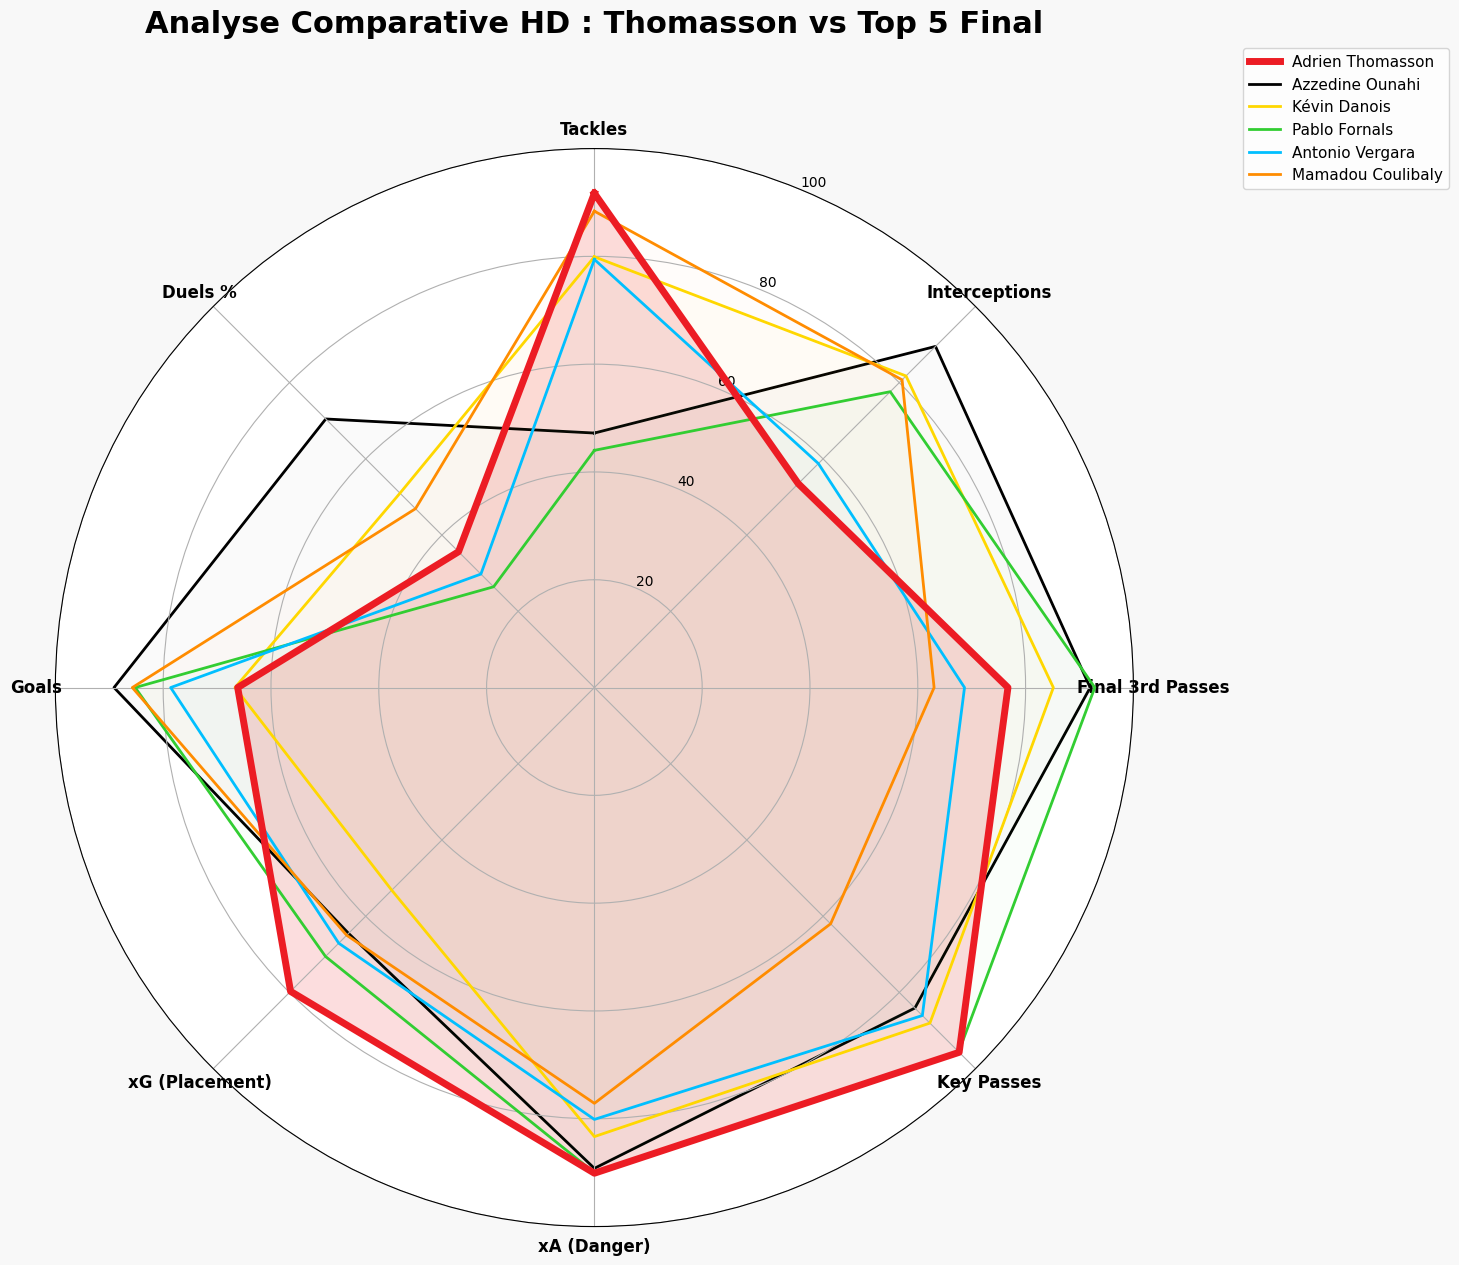

In [92]:


# 1. La shortlist finale (Nettoyée des faux-positifs)
shortlist_noms = [
    "Azzedine Ounahi",   # Le choix Expérience/Risque
    "Kévin Danois",      # Le jeune espoir L1
    "Pablo Fornals",     # La valeur sûre Liga/PL
    "Antonio Vergara",   # La pépite technique
    "Mamadou Coulibaly"  # La puissance athlétique
]

tous_les_profils = ['Adrien Thomasson'] + shortlist_noms

# 2. Configuration des 8 axes HD
categories_det = [
    'Tackles', 'Interceptions', 'Final 3rd Passes', 'Key Passes', 
    'xA (Danger)', 'xG (Placement)', 'Goals', 'Duels %'
]
cols_det = [
    'tackles_p90_pct', 'interceptions_p90_pct', 'accurateFinalThirdPasses_p90_pct', 
    'keyPasses_p90_pct', 'expectedAssists_p90_pct', 'expectedGoals_p90_pct', 
    'goals_p90_pct', 'groundDuelsWonPercentage_pct'
]

# Palette : Rouge vif pour Thomasson, puis des couleurs pour les 5 cibles
couleurs = ['#EC1C24', '#000000', '#FFD700', '#32CD32', '#00BFFF', '#FF8C00']

angles = np.linspace(0, 2*np.pi, len(categories_det), endpoint=False).tolist()
angles += angles[:1] 

plt.figure(figsize=(14, 14), facecolor='#f8f8f8')
ax = plt.subplot(111, polar=True)

# Boucle de traçage
for i, nom in enumerate(tous_les_profils):
    if nom == 'Adrien Thomasson':
        df_j = df_final[df_final['player__name'].str.contains('Thomasson', na=False)]
    else:
        df_j = df_final[df_final['player__name'] == nom]
    
    if not df_j.empty:
        values = df_j[cols_det].values.flatten().tolist()
        values += values[:1] 
        
        is_ref = (nom == 'Adrien Thomasson')
        lw = 5 if is_ref else 2
        z = 10 if is_ref else i
        alpha_fill = 0.15 if is_ref else 0.02 
        
        ax.plot(angles, values, color=couleurs[i], linewidth=lw, label=nom, zorder=z)
        ax.fill(angles, values, color=couleurs[i], alpha=alpha_fill)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories_det, fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)

plt.title("Analyse Comparative HD : Thomasson vs Top 5 Final", size=22, y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11, frameon=True)

plt.show()

### Analyse Détaillée du Radar HD : La Double Vision (Data & Sportif)

**1. Lecture Géométrique :**
Le radar valide visuellement notre modèle mathématique (Similarité Cosinus). L'objectif n'était pas de trouver le polygone le plus grand, mais la **même empreinte géométrique** qu'Adrien Thomasson.
* **La Superposition Parfaite (Pablo Fornals) :** Son polygone englobe la référence avec une précision chirurgicale, et offre même un surplus sur la progression de la balle (*Final 3rd Passes*). C'est l'amélioration "Premium" du modèle.
* **Le Biais Contextuel (Kévin Danois) :** Son graphique est décalé vers la gauche (*Tackles, Interceptions*) et en retrait à droite (*xG, Goals*). La data s'explique par son environnement : Auxerre subit le jeu, l'obligeant à surperformer défensivement. 
* **La Variante Créative (Antonio Vergara) :** Sa surface présente une pointe agressive vers les *Key Passes* et *xA*. Il "déforme" l'ADN de Thomasson vers un profil de pur meneur de jeu reculé.

**2. Stratégie & Risque :**
* **Fornals** est le joueur "Win-Now". Si l'on joue la Coupe d'Europe en septembre, son polygone prouve qu'il peut encaisser la haute intensité de Pierre Sage sans baisse de régime.
* **Danois** est le diamant brut. Transféré dans l'équipe dominante du RC Lens, sa production offensive s'étendra naturellement pour combler le côté droit de son radar.
* **Vergara** offre une arme différente. Si le coach veut un milieu capable de forcer le verrou des blocs bas de Ligue 1 avec des passes clés, c'est l'homme de la situation.

# 8. Recommandations Scouting & Verdict

# 8. Recommandations Scouting & Verdict Final
### 🏆 1. Le Podium (Shortlist Définitive)

Au croisement des données statistiques, de la cohérence tactique et des limites budgétaires (< 20 M€), voici la recommandation finale de la cellule de recrutement :

| Rang | Joueur | Âge | Club | Valeur | Statut | Profil Stratégique (Argumentaire) | Risque |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 🥇 **1er** | **Pablo Fornals** | 29 ans | Real Betis | 8,00 M€ | L'Assurance Tous Risques | Coche toutes les cases : coffre athlétique, technique Liga, et expérience européenne. Maintient le niveau de l'équipe immédiatement. | Exigences salariales élevées (historique Premier League/Liga). |
| 🥈 **2e** | **Kévin Danois** | 21 ans | AJ Auxerre | 10,00 M€ | Le Projet Club | Le clone data parfait en devenir. Moteur physique idéal pour le système Sage. Forte valeur de revente (modèle Openda/Wahi). | Inexpérience du très haut niveau pour la Coupe d'Europe. |
| 🥉 **3e** | **Antonio Vergara** | 23 ans | SSC Napoli | 2,50 M€ | L'Opportunité Moneyball | Créateur pur à la technique soyeuse, idéal pour débloquer les matchs fermés. Risque financier quasi nul pour le club. | Adaptation à l'impact athlétique brutal des milieux de Ligue 1. |

---

### 💡 2. Le Dossier Hors-Catégorie : Azzedine Ounahi

L'algorithme a positionné **Azzedine Ounahi** (10,00 M€) tout en haut de la liste. Bien que nous l'ayons écarté du podium principal pour des raisons de viabilité, une réflexion stratégique s'impose. 

Il a la connaissance parfaite de la Ligue 1, l'expérience du très haut niveau (Coupe du Monde) et le leadership d'un cadre international. **Si les cellules médicales et les préparateurs physiques estiment pouvoir trouver une solution pérenne à ses blessures chroniques (mollets, dos), Azzedine Ounahi serait factuellement la pioche manquante absolue dans le système de Pierre Sage.** C'est un pari à haut risque médical, mais à la récompense sportive inestimable.

---

### 🎯 3. Synthèse du Projet

Le *Thomasson Engine* démontre qu'il est possible de remplacer l'un de nos cadres historiques de manière rationnelle. En s'appuyant sur des datas standardisées (Z-Score inter-ligues), une pondération tactique pointue, et une analyse financière rigoureuse, nous sommes passés d'une base de **2445 joueurs européens** à une liste de **3 cibles concrètes et actionnables** pour la direction sportive.